# Actividad 4.1

**Curso:** Desarrollo de aplicaciones avanzadas de ciencias computacionales (Gpo 570)  
**Profesor:** Luis Ricardo Peña Llamas  
**Alumno:** Fernando Daniel Monroy Sánchez (A01750536)  
**Fecha:** 8 de octubre de 2026  

---

## 1. Introducción

El propósito de esta actividad es identificar procesos reales cotidianos y modelarlos mediante funciones de densidad de probabilidad continuas.

Se analiza la movilidad y afluencia urbana en Nueva York usando datos de Foursquare (dataset TSMC2014) con 227428 checkins recolectados entre abril de 2012 y febrero de 2013 en 251 categorías de lugares.

Se definieron dos atributos principales:
* **Atributo principal:** Total de visitas diarias registradas por categoría (variable cuantitativa discreta).
* **Atributo complementario:** Hora local de llegada de cada visita (0 a 23 hrs) para modelar los ciclos circadianos de afluencia.

*(Ver [Apéndice A](#apéndice-a-carga-de-datos) para el código de carga y preprocesamiento)*

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from fitter import Fitter
from great_tables import GT

import re

# Habilitar soporte de tablas en LaTeX para exportacion a PDF igualando fuente del documento
def _gt_to_latex(self):
    latex_str = self.as_latex()
    latex_str = re.sub(r"\\begin\{table\}(\[[^\]]*\])?", r"\\begin{table}[H]\n\\centering", latex_str)
    latex_str = latex_str.replace(r"\begin{tabular*}{\linewidth}", r"\begin{tabular*}{0.75\linewidth}")
    latex_str = re.sub(r"\\fontsize\{[^}]+\}\{[^}]+\}\\selectfont", r"\\normalsize", latex_str)
    latex_str = re.sub(r"\\caption\*\{\s*\{\\large\s+([^\}]+)\}\s*\}", r"\\caption*{\\textbf{\\normalsize \1}}", latex_str)
    return latex_str

GT._repr_latex_ = _gt_to_latex

from act_1.data_loader import (
    get_daily_counts,
    load_raw_data,
    preprocess_checkins,
)

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["axes.edgecolor"] = "#CBD5E0"
plt.rcParams["axes.linewidth"] = 0.8

In [2]:
# Carga de datos y resumen general del dataset
df_raw = load_raw_data()
df = preprocess_checkins(df_raw)

overview_data = pd.DataFrame([
    {"Métrica": "Total de observaciones", "Valor": f"{len(df):,}"},
    {"Métrica": "Período temporal", "Valor": f"{df['date'].min()} al {df['date'].max()}"},
    {"Métrica": "Categorías registradas", "Valor": str(df["category_name"].nunique())},
])

gt_overview = (
    GT(overview_data)
    .tab_header(title="Resumen del Dataset (Foursquare NYC)")
    .cols_align(align="left", columns=["Métrica"])
    .cols_align(align="right", columns=["Valor"])
)
gt_overview

GT(_tbl_data=                  Métrica                     Valor
0  Total de observaciones                   227,428
1        Período temporal  2012-04-03 al 2013-02-15
2  Categorías registradas                       251, _body=<great_tables._gt_data.Body object at 0x11080a3c0>, _boxhead=Boxhead([ColInfo(var='Métrica', type=<ColInfoTypeEnum.default: 1>, column_label='Métrica', column_align='left', column_width=None), ColInfo(var='Valor', type=<ColInfoTypeEnum.default: 1>, column_label='Valor', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x11080a120>, _spanners=Spanners([]), _heading=Heading(title='Resumen del Dataset (Foursquare NYC)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x11080a7b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1107bf110>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x11080a900>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='center'), heading_title_font_size=OptionsInfo(scss=T

```{=latex}
\newpage
```

## 2. Desarrollo

Se analizan tres categorías de lugares con naturalezas operativas distintas:
* **Bar:** Actividad social nocturna concentrada en fines de semana.
* **Park:** Espacio público al aire libre condicionado por el clima y tiempo libre.
* **College Academic Building:** Espacio universitario con horarios estructurados entre semana.

### 2.1. Histogramas

En clase vimos que la PDF concentra probabilidad cerca de la media y que la dispersión la rige la varianza. Como mencionó el profesor Luis Ricardo Peña Llamas con el ejemplo de Google Maps, la afluencia urbana no suele ser simétrica sino que exhibe colas hacia la derecha por picos de demanda.

Inspeccionando los histogramas diarios:
* **Bar:** Concentración base entre semana y cola larga por viernes y sábados. Se asemeja a **Weibull** o **Gamma**.
* **Park:** Soporte no negativo con asimetría moderada. Coincide con una **Log normal**.
* **College Academic Building:** Fuerte demanda en días hábiles y caída en fines de semana. Se asemeja a **Gamma** o **Exponencial**.

*(Ver [Apéndice B](#apéndice-b-histogramas) para el código de graficación)*

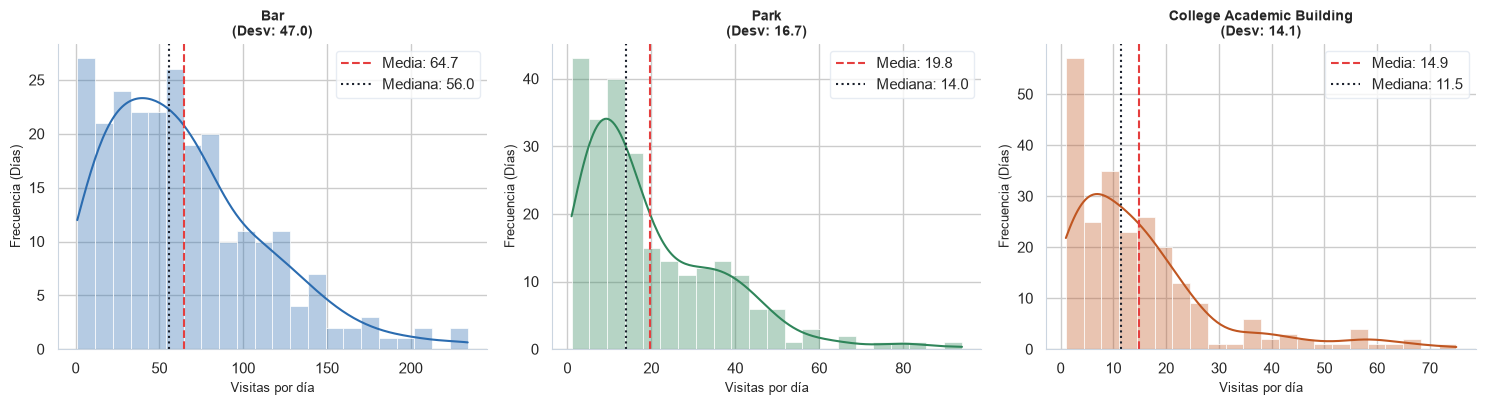

In [3]:
# Histogramas comparativos de afluencia diaria
target_categories = ["Bar", "Park", "College Academic Building"]
palette = {
    "Bar": "#2B6CB0",
    "Park": "#2F855A",
    "College Academic Building": "#C05621",
}

daily_data = {cat: get_daily_counts(df, cat) for cat in target_categories}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, cat in zip(axes, target_categories):
    counts = daily_data[cat]
    color = palette[cat]
    
    sns.histplot(
        counts,
        kde=True,
        ax=ax,
        color=color,
        bins=22,
        alpha=0.35,
        edgecolor="#FFFFFF",
        linewidth=0.5,
    )
    
    mean_val = counts.mean()
    median_val = counts.median()
    std_val = counts.std()
    
    ax.axvline(
        mean_val,
        color="#E53E3E",
        linestyle="--",
        lw=1.5,
        label=f"Media: {mean_val:.1f}",
    )
    ax.axvline(
        median_val,
        color="#1A202C",
        linestyle=":",
        lw=1.5,
        label=f"Mediana: {median_val:.1f}",
    )
    
    ax.set_title(
        f"{cat}\n(Desv: {std_val:.1f})",
        fontsize=10,
        fontweight="bold",
    )
    ax.set_xlabel("Visitas por día", fontsize=9)
    ax.set_ylabel("Frecuencia (Días)", fontsize=9)
    ax.legend(frameon=True, facecolor="#FFFFFF", edgecolor="#E2E8F0")
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

*Nota sobre lectura de histogramas:* El eje x mide visitas diarias y el eje y cuenta días. La línea roja discontinua es la media y la negra punteada es la mediana. La brecha entre ambas muestra la asimetría positiva por picos de fin de semana.

### 2.2. Comparación visual

A continuación se contrastan las observaciones empíricas con las funciones de densidad teóricas de referencia vistas en clase.

*(Ver [Apéndice C](#apéndice-c-comparación-visual) para el código de los paneles)*

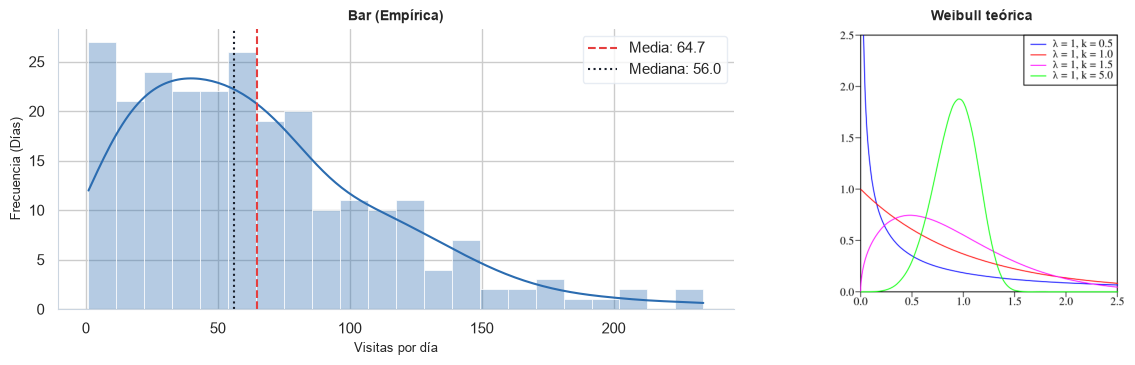

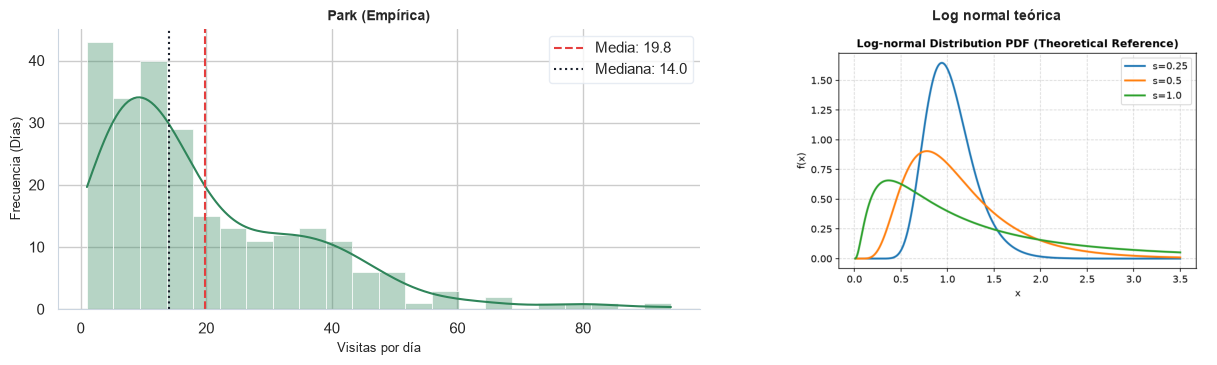

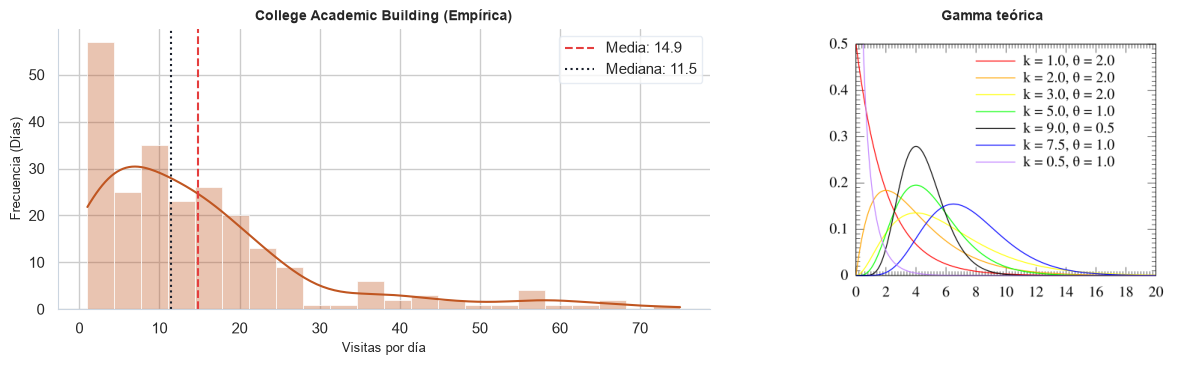

In [4]:
# Paneles comparativos lado a lado
images_base = Path("images") if Path("images").exists() else Path("notebooks/images")

ref_info = {
    "Bar": (
        images_base / "weibull_dist.png",
        "Weibull teórica",
    ),
    "Park": (
        images_base / "lognormal_dist.png",
        "Log normal teórica",
    ),
    "College Academic Building": (
        images_base / "gamma_dist.png",
        "Gamma teórica",
    ),
}

for cat in target_categories:
    counts = daily_data[cat]
    img_path, ref_title = ref_info[cat]
    
    fig, axes = plt.subplots(
        1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.15, 1.0]}
    )
    
    sns.histplot(
        counts,
        kde=True,
        ax=axes[0],
        color=palette[cat],
        bins=22,
        alpha=0.35,
        edgecolor="#FFFFFF",
        linewidth=0.5,
    )
    axes[0].axvline(
        counts.mean(),
        color="#E53E3E",
        linestyle="--",
        lw=1.5,
        label=f"Media: {counts.mean():.1f}",
    )
    axes[0].axvline(
        counts.median(),
        color="#1A202C",
        linestyle=":",
        lw=1.5,
        label=f"Mediana: {counts.median():.1f}",
    )
    axes[0].set_title(
        f"{cat} (Empírica)",
        fontsize=10,
        fontweight="bold",
    )
    axes[0].set_xlabel("Visitas por día", fontsize=9)
    axes[0].set_ylabel("Frecuencia (Días)", fontsize=9)
    axes[0].legend(frameon=True, facecolor="#FFFFFF", edgecolor="#E2E8F0")
    sns.despine(ax=axes[0])
    
    ref_image = mpimg.imread(img_path)
    axes[1].imshow(ref_image)
    axes[1].axis("off")
    axes[1].set_title(ref_title, fontsize=10, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

*Nota sobre comparación teórica:* El panel izquierdo muestra la densidad estimada (KDE) y el derecho la PDF teórica. Se busca coincidencia en el umbral de inicio, la moda y el decaimiento de la cola derecha.

### 2.3. Distribución horaria

La hora de llegada complementa el análisis mostrando cómo la función del espacio modula el ciclo diario:
* **Bar:** Concentración nocturna unimodal con pico a las 22:00 hrs.
* **College Academic Building:** Meseta matutina con pico a las 08:00 hrs y decaimiento desde las 14:00 hrs.

*(Ver [Apéndice D](#apéndice-d-distribución-horaria) para el código de la distribución horaria)*

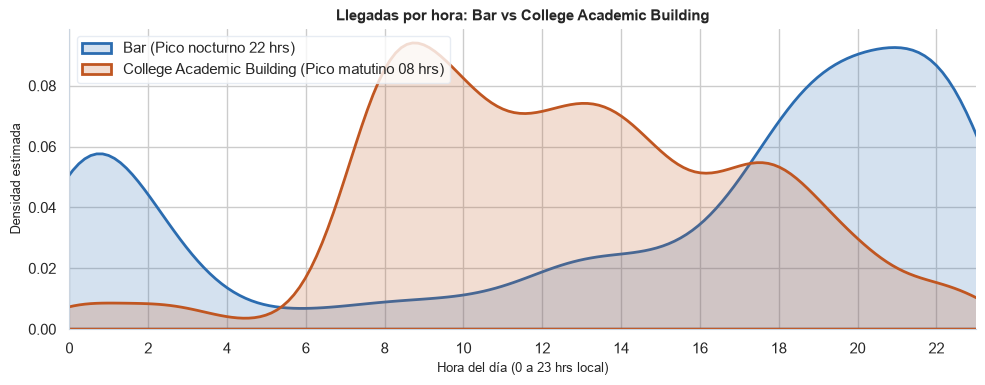

In [5]:
# Densidad horaria de llegadas
fig, ax = plt.subplots(figsize=(10, 4.0))

bar_hours = df[df["category_name"] == "Bar"]["hour"]
college_hours = df[df["category_name"] == "College Academic Building"]["hour"]

sns.kdeplot(
    bar_hours,
    ax=ax,
    label="Bar (Pico nocturno 22 hrs)",
    color=palette["Bar"],
    lw=2.0,
    fill=True,
    alpha=0.20,
)

sns.kdeplot(
    college_hours,
    ax=ax,
    label="College Academic Building (Pico matutino 08 hrs)",
    color=palette["College Academic Building"],
    lw=2.0,
    fill=True,
    alpha=0.20,
)

ax.set_title(
    "Llegadas por hora: Bar vs College Academic Building",
    fontsize=11,
    fontweight="bold",
)
ax.set_xlabel("Hora del día (0 a 23 hrs local)", fontsize=9)
ax.set_ylabel("Densidad estimada", fontsize=9)
ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True, facecolor="#FFFFFF", edgecolor="#E2E8F0", loc="upper left")
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

*Nota sobre distribución horaria:* Modela la probabilidad de llegada según la hora local en Nueva York, útil para dimensionar personal como vimos con el ejemplo de Google Maps en clase.

### 2.4. Ajuste con Fitter

Se ajustan seis familias continuas con Fitter (`norm`, `lognorm`, `gamma`, `expon`, `weibull_min`, `rayleigh`).
La bondad de ajuste se evalúa con la suma de errores cuadráticos (SSE) contra el histograma normalizado.

*(Ver [Apéndice E](#apéndice-e-ajuste-con-fitter) para el código de ajuste y tablas)*

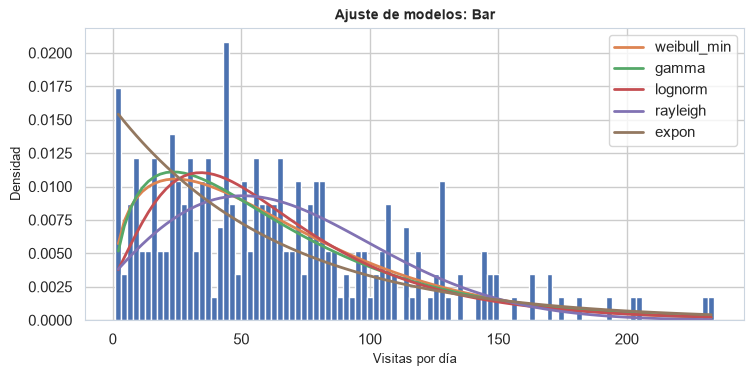

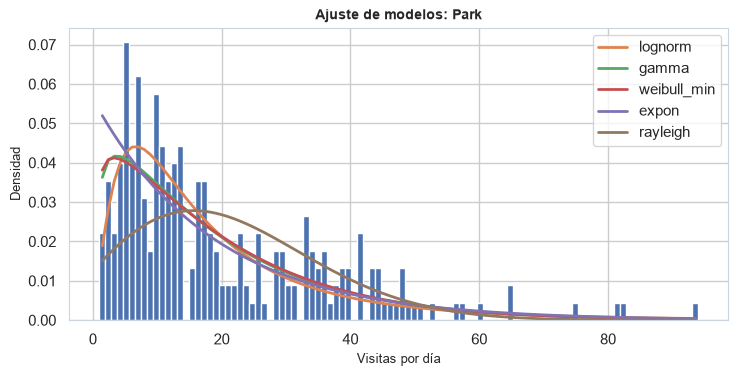

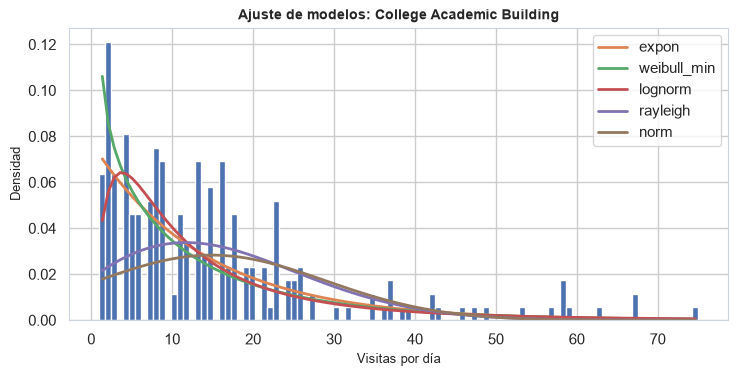

In [6]:
candidate_distributions = [
    "norm",
    "lognorm",
    "gamma",
    "expon",
    "weibull_min",
    "rayleigh",
]
fitter_results = {}

for cat in target_categories:
    data = daily_data[cat].values
    fitter_instance = Fitter(data, distributions=candidate_distributions, timeout=30)
    fitter_instance.fit()
    fitter_results[cat] = fitter_instance
    
    plt.figure(figsize=(8.5, 3.8))
    fitter_instance.summary()
    plt.title(f"Ajuste de modelos: {cat}", fontsize=10, fontweight="bold")
    plt.xlabel("Visitas por día", fontsize=9)
    plt.ylabel("Densidad", fontsize=9)
    plt.show()

*Nota sobre curvas de ajuste:* Las trazas continuas son densidades paramétricas ajustadas por máxima verosimilitud. El modelo de menor SSE es la representación óptima.

In [7]:
# Clasificación de las 3 mejores distribuciones por categoría
ranking_records = []
for cat in target_categories:
    summary_top = fitter_results[cat].summary(plot=False).head(3).reset_index()
    for _, row in summary_top.iterrows():
        ranking_records.append({
            "Categoría": cat,
            "Distribución": row["index"],
            "SSE": row["sumsquare_error"],
            "AIC": row["aic"],
            "BIC": row["bic"],
        })

ranking_df = pd.DataFrame(ranking_records)
gt_ranking = (
    GT(ranking_df, groupname_col="Categoría")
    .tab_header(title="Comparativa de Modelos Candidatos (Top 3 por Categoría)")
    .fmt_number(columns=["SSE"], decimals=6)
    .fmt_number(columns=["AIC", "BIC"], decimals=2)
)
gt_ranking

GT(_tbl_data=                   Categoría Distribución       SSE          AIC          BIC
0                        Bar  weibull_min  0.000907  2529.982986  2540.511151
1                        Bar        gamma  0.000945  2535.948870  2546.477035
2                        Bar      lognorm  0.000956  2548.246123  2558.774288
3                       Park      lognorm  0.006459  1927.654581  1938.133765
4                       Park        gamma  0.006965  1915.659722  1926.138906
5                       Park  weibull_min  0.007115  1914.791075  1925.270260
6  College Academic Building        expon  0.024777  1702.629172  1709.539815
7  College Academic Building  weibull_min  0.026292  1611.618031  1621.983995
8  College Academic Building      lognorm  0.027759  1732.855148  1743.221111, _body=<great_tables._gt_data.Body object at 0x1138c2210>, _boxhead=Boxhead([ColInfo(var='Categoría', type=<ColInfoTypeEnum.row_group: 3>, column_label='Categoría', column_align='left', column_width=None), ColInfo(var='Distribución', type=<ColInfoTypeEnum.default: 1>, column_label='Distribución', column_align='left', column_width=None), ColInfo(var='SSE', type=<ColInfoTypeEnum.default: 1>, column_label='SSE', column_align='right', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x113bf1090>, _spanners=Spanners([]), _heading=Heading(title='Comparativa de Modelos Candidatos (Top 3 por Categoría)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x113bf1810>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x113674510>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x113bf1950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1134c9be0>, <great_tables._gt_data.FormatInfo object at 0x113bf1bd0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_bord

### 2.5. Parámetros óptimos

Los parámetros óptimos estimados por máxima verosimilitud son:

1. **Bar $\rightarrow$ `weibull_min` (Weibull):**
   * Forma ($c = 1.323$): Al ser $c > 1$, describe tasa variable con asimetría positiva y decaimiento suave.
   * Localización ($loc = 0.436$): Soporte continuo iniciando cerca de cero.
   * Escala ($scale = 69.541$): Escala volumétrica típica de visitas diarias.

2. **Park $\rightarrow$ `lognorm` (Log normal):**
   * Forma ($s = 0.817$): Dispersión de la variable en escala logarítmica.
   * Localización ($loc = -1.266$): Traslación del soporte real.
   * Escala ($scale = 15.440$): Mediana de visitas diarias ($e^\mu = 15.440$).

3. **College Academic Building $\rightarrow$ `expon` (Exponencial):**
   * Localización ($loc = 1.000$): Umbral mínimo de visitas diarias.
   * Escala ($scale = 13.868$): Inverso de tasa ($1/\lambda = 13.868$), indicando la media de visitas adicionales.

In [8]:
# Tabla consolidada de parámetros
records = []
for cat in target_categories:
    f = fitter_results[cat]
    best_dict = f.get_best()
    model_name = list(best_dict.keys())[0]
    raw_params = best_dict[model_name]
    best_sse = f.summary(plot=False).loc[model_name, "sumsquare_error"]
    
    formatted_params = ", ".join([
        f"{k}={v:.3f}" if isinstance(v, (int, float, np.floating)) else f"{k}={v}"
        for k, v in raw_params.items()
    ])
    
    records.append({
        "Categoría": cat,
        "Modelo Óptimo": model_name,
        "SSE": best_sse,
        "Parámetros Identificados": formatted_params,
    })

params_df = pd.DataFrame(records)
gt_params = (
    GT(params_df)
    .tab_header(title="Parámetros Óptimos Identificados")
    .fmt_number(columns=["SSE"], decimals=6)
    .cols_align(align="left", columns=["Categoría", "Modelo Óptimo", "Parámetros Identificados"])
    .cols_align(align="right", columns=["SSE"])
)
gt_params

GT(_tbl_data=                   Categoría Modelo Óptimo       SSE  \
0                        Bar   weibull_min  0.000907   
1                       Park       lognorm  0.006459   
2  College Academic Building         expon  0.024777   

            Parámetros Identificados  
0   c=1.323, loc=0.436, scale=69.541  
1  s=0.817, loc=-1.266, scale=15.440  
2            loc=1.000, scale=13.868  , _body=<great_tables._gt_data.Body object at 0x1137659a0>, _boxhead=Boxhead([ColInfo(var='Categoría', type=<ColInfoTypeEnum.default: 1>, column_label='Categoría', column_align='left', column_width=None), ColInfo(var='Modelo Óptimo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo Óptimo', column_align='left', column_width=None), ColInfo(var='SSE', type=<ColInfoTypeEnum.default: 1>, column_label='SSE', column_align='right', column_width=None), ColInfo(var='Parámetros Identificados', type=<ColInfoTypeEnum.default: 1>, column_label='Parámetros Identificados', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x113676780>, _spanners=Spanners([]), _heading=Heading(title='Parámetros Óptimos Identificados', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1136776f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1138c29f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x113bf2490>, _formats=[<great_tables._gt_data.FormatInfo object at 0x113bf2350>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='

```{=latex}
\newpage
```

## 3. Reflexión

Uno empieza pensando que todo va a dar una campana normal, pero en la vida real casi nada en una ciudad es simétrico. Como decía el profe Ricardo Peña en clase, ajustar distribuciones es hacer ingeniería inversa sobre la data cruda. En los bares nos dio Weibull con scale de 69 visitas diarias y la forma mayor a 1 refleja justo que la gente revienta los lugares el fin de semana en vez de repartirse pareja.

En parques salió Log normal porque el buen clima o los descansos multiplican la afluencia en lugar de sumarla. Al final la razón de hacer esto es simular. Cargar un dataset de 227 mil rows para correr un escenario es pesadísimo; mejor guardas tres parámetros y generas datos sintéticos con transformada inversa. Es como el ejemplo de colas de Walmart y la zapatería que vimos: para saber si meter una segunda caja basta simular llegadas continuas sin arrastrar todo el historial.

Además la distribución sirve como un fingerprint del proceso. Un bar en Nueva York o un antro en Monterrey comparten la misma curva con cola larga a la derecha, mientras que un edificio escolar decae en fin de semana. El tipo de negocio manda sobre la forma.

Obvio los checkins de Foursquare tienen sesgo hacia gente joven con smartphone en 2012, pero el patrón queda claro. No buscamos ecuaciones perfectas, sino un modelo compacto que sirva para decidir rápido.

```{=latex}
\newpage
```

## 4. Apéndices

Códigos fuente empleados para el procesamiento, modelación y graficación del reporte.

### Apéndice A: Carga de datos

```python
from pathlib import Path
import pandas as pd
from great_tables import GT
from act_1.data_loader import (
    get_daily_counts,
    load_raw_data,
    preprocess_checkins,
)

df_raw = load_raw_data()
df = preprocess_checkins(df_raw)

overview_data = pd.DataFrame([
    {"Métrica": "Total de observaciones", "Valor": f"{len(df):,}"},
    {"Métrica": "Período temporal", "Valor": f"{df['date'].min()} al {df['date'].max()}"},
    {"Métrica": "Categorías registradas", "Valor": str(df["category_name"].nunique())},
])

gt_overview = (
    GT(overview_data)
    .tab_header(title="Resumen del Dataset (Foursquare NYC)")
    .cols_align(align="left", columns=["Métrica"])
    .cols_align(align="right", columns=["Valor"])
)
gt_overview
```

```{=latex}
\newpage
```

### Apéndice B: Histogramas

```python
import matplotlib.pyplot as plt
import seaborn as sns

target_categories = ["Bar", "Park", "College Academic Building"]
palette = {
    "Bar": "#2B6CB0",
    "Park": "#2F855A",
    "College Academic Building": "#C05621",
}

daily_data = {cat: get_daily_counts(df, cat) for cat in target_categories}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, cat in zip(axes, target_categories):
    counts = daily_data[cat]
    sns.histplot(
        counts,
        kde=True,
        ax=ax,
        color=palette[cat],
        bins=22,
        alpha=0.35,
        edgecolor="#FFFFFF",
        linewidth=0.5,
    )
    mean_val = counts.mean()
    median_val = counts.median()
    std_val = counts.std()
    ax.axvline(
        mean_val, color="#E53E3E", linestyle="--", lw=1.5,
        label=f"Media: {mean_val:.1f}",
    )
    ax.axvline(
        median_val, color="#1A202C", linestyle=":", lw=1.5,
        label=f"Mediana: {median_val:.1f}",
    )
    ax.set_title(f"{cat}\n(Desv: {std_val:.1f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Visitas por día", fontsize=9)
    ax.set_ylabel("Frecuencia (Días)", fontsize=9)
    ax.legend(frameon=True)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()
```

```{=latex}
\newpage
```

### Apéndice C: Comparación visual

```python
import matplotlib.image as mpimg

images_base = Path("images") if Path("images").exists() else Path("notebooks/images")
ref_info = {
    "Bar": (images_base / "weibull_dist.png", "Weibull teórica"),
    "Park": (images_base / "lognormal_dist.png", "Log normal teórica"),
    "College Academic Building": (images_base / "gamma_dist.png", "Gamma teórica"),
}

for cat in target_categories:
    counts = daily_data[cat]
    img_path, ref_title = ref_info[cat]
    fig, axes = plt.subplots(
        1, 2, figsize=(13, 3.8),
        gridspec_kw={"width_ratios": [1.15, 1.0]},
    )
    sns.histplot(
        counts, kde=True, ax=axes[0],
        color=palette[cat], bins=22, alpha=0.35,
    )
    axes[0].set_title(f"{cat} (Empírica)", fontsize=10, fontweight="bold")
    axes[0].legend(frameon=True)
    sns.despine(ax=axes[0])
    ref_image = mpimg.imread(img_path)
    axes[1].imshow(ref_image)
    axes[1].axis("off")
    axes[1].set_title(ref_title, fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()
```

```{=latex}
\newpage
```

### Apéndice D: Distribución horaria

```python
fig, ax = plt.subplots(figsize=(10, 4.0))
bar_hours = df[df["category_name"] == "Bar"]["hour"]
college_hours = df[df["category_name"] == "College Academic Building"]["hour"]

sns.kdeplot(
    bar_hours, ax=ax, label="Bar (Pico nocturno 22 hrs)",
    color=palette["Bar"], lw=2.0, fill=True, alpha=0.20,
)
sns.kdeplot(
    college_hours, ax=ax,
    label="College Academic Building (Pico matutino 08 hrs)",
    color=palette["College Academic Building"],
    lw=2.0, fill=True, alpha=0.20,
)
ax.set_title("Llegadas por hora: Bar vs College Academic Building", fontsize=11, fontweight="bold")
ax.set_xlabel("Hora del día (0 a 23 hrs local)", fontsize=9)
ax.set_ylabel("Densidad estimada", fontsize=9)
ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True, loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
```

```{=latex}
\newpage
```

### Apéndice E: Ajuste con Fitter

```python
from fitter import Fitter
from great_tables import GT

candidate_distributions = [
    "norm", "lognorm", "gamma", "expon", "weibull_min", "rayleigh"
]
fitter_results = {}
ranking_records, records = [], []

for cat in target_categories:
    data = daily_data[cat].values
    f = Fitter(data, distributions=candidate_distributions, timeout=30)
    f.fit()
    fitter_results[cat] = f
    
    summary_top = f.summary(plot=False).head(3).reset_index()
    for _, row in summary_top.iterrows():
        ranking_records.append({
            "Categoría": cat,
            "Distribución": row["index"],
            "SSE": row["sumsquare_error"],
            "AIC": row["aic"],
            "BIC": row["bic"],
        })
    
    best_name = list(f.get_best().keys())[0]
    raw_p = f.get_best()[best_name]
    p_str = ", ".join([
        f"{k}={v:.3f}" if isinstance(v, (int, float, np.floating)) else f"{k}={v}"
        for k, v in raw_p.items()
    ])
    records.append({
        "Categoría": cat,
        "Modelo Óptimo": best_name,
        "SSE": f.summary(plot=False).loc[best_name, "sumsquare_error"],
        "Parámetros Identificados": p_str,
    })

gt_ranking = (
    GT(pd.DataFrame(ranking_records), groupname_col="Categoría")
    .tab_header(title="Comparativa de Modelos Candidatos (Top 3 por Categoría)")
    .fmt_number(columns=["SSE"], decimals=6)
    .fmt_number(columns=["AIC", "BIC"], decimals=2)
)
gt_params = (
    GT(pd.DataFrame(records))
    .tab_header(title="Parámetros Óptimos Identificados")
    .fmt_number(columns=["SSE"], decimals=6)
)
```